# Notebook 02: Bedrock Knowledge Base Management

## Overview

In this notebook, we will:
1. Connect to AWS Bedrock Knowledge Base
2. Trigger and monitor ingestion jobs
3. Explore the indexed data structure
4. Test retrieval with various queries
5. Visualize retrieval scores and relevance
6. Understand how vector search works

**Learning Objectives:**
- Understand how to manage Knowledge Bases programmatically
- Learn how to sync new data to the vector store
- See what the indexed data looks like
- Understand retrieval scores and ranking
- Prepare for building the RAG application

---

## 1. Setup and Configuration

In [1]:
import os
import json
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from dotenv import load_dotenv
import time

# Load environment variables
load_dotenv()

# Configuration
KNOWLEDGE_BASE_ID = os.getenv('KNOWLEDGE_BASE_ID')
AWS_REGION = os.getenv('AWS_DEFAULT_REGION', 'us-east-1')

# Initialize Bedrock clients
bedrock_agent = boto3.client('bedrock-agent', region_name=AWS_REGION)
bedrock_agent_runtime = boto3.client('bedrock-agent-runtime', region_name=AWS_REGION)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print(f"[OK] Configuration loaded")
print(f"  Knowledge Base ID: {KNOWLEDGE_BASE_ID}")
print(f"  Region: {AWS_REGION}")

[OK] Configuration loaded
  Knowledge Base ID: HAMKFMPMEM
  Region: us-east-1


/Users/apalakkode/Library/CloudStorage/OneDrive-PayPal/Agentic RAG/ecommerce-chatbot/venv/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


---

## 2. Knowledge Base Details

Let's inspect the Knowledge Base configuration.

In [2]:
# Get Knowledge Base details
kb_response = bedrock_agent.get_knowledge_base(knowledgeBaseId=KNOWLEDGE_BASE_ID)
kb = kb_response['knowledgeBase']

print("Knowledge Base Information:")
print("="*80)
print(f"Name: {kb['name']}")
print(f"ID: {kb['knowledgeBaseId']}")
print(f"Status: {kb['status']}")
print(f"Created: {kb['createdAt']}")
print(f"Updated: {kb['updatedAt']}")
print(f"Role ARN: {kb['roleArn']}")

# Extract configuration details
kb_config = kb['knowledgeBaseConfiguration']
print("\nConfiguration:")
print("-"*80)
print(f"Type: {kb_config['type']}")

if 'vectorKnowledgeBaseConfiguration' in kb_config:
    vector_config = kb_config['vectorKnowledgeBaseConfiguration']
    print(f"Embedding Model: {vector_config['embeddingModelArn']}")

# Storage configuration
storage_config = kb['storageConfiguration']
print("\nStorage:")
print("-"*80)
print(f"Type: {storage_config['type']}")

if 'opensearchServerlessConfiguration' in storage_config:
    oss_config = storage_config['opensearchServerlessConfiguration']
    print(f"Collection ARN: {oss_config['collectionArn']}")
    print(f"Vector Index: {oss_config['vectorIndexName']}")

Knowledge Base Information:
Name: knowledge-base-v2
ID: HAMKFMPMEM
Status: ACTIVE
Created: 2026-01-18 13:26:27.144763+00:00
Updated: 2026-01-18 13:26:27.144763+00:00
Role ARN: arn:aws:iam::060795897274:role/service-role/AmazonBedrockExecutionRoleForKnowledgeBase_txj6j

Configuration:
--------------------------------------------------------------------------------
Type: VECTOR
Embedding Model: arn:aws:bedrock:us-east-1::foundation-model/amazon.titan-embed-text-v2:0

Storage:
--------------------------------------------------------------------------------
Type: OPENSEARCH_SERVERLESS
Collection ARN: arn:aws:aoss:us-east-1:060795897274:collection/iweerr8y00es9yjb0r9g
Vector Index: bedrock-knowledge-base-default-index


---

## 3. Data Source Management

View and manage data sources connected to the Knowledge Base.

In [3]:
# List data sources
ds_response = bedrock_agent.list_data_sources(knowledgeBaseId=KNOWLEDGE_BASE_ID)

print("Data Sources:")
print("="*80)

data_sources = []
for ds in ds_response['dataSourceSummaries']:
    data_sources.append({
        'Name': ds['name'],
        'ID': ds['dataSourceId'],
        'Status': ds['status'],
        'Updated': ds['updatedAt']
    })
    
ds_df = pd.DataFrame(data_sources)
print(ds_df.to_string(index=False))

# Save first data source ID for later use
DATA_SOURCE_ID = ds_response['dataSourceSummaries'][0]['dataSourceId']
print(f"\n[INFO] Using Data Source ID: {DATA_SOURCE_ID}")

Data Sources:
                                        Name         ID    Status                          Updated
knowledge-base-quick-start-yzdb1-data-source XFMED6E2YR AVAILABLE 2026-01-18 13:26:28.264545+00:00

[INFO] Using Data Source ID: XFMED6E2YR


---

## 4. Ingestion Job History

View past ingestion jobs to understand sync history.

In [5]:
# List ingestion jobs
jobs_response = bedrock_agent.list_ingestion_jobs(
    knowledgeBaseId=KNOWLEDGE_BASE_ID,
    dataSourceId=DATA_SOURCE_ID,
    maxResults=10
)

print("Ingestion Job History:")
print("="*80)

jobs_data = []
for job in jobs_response.get('ingestionJobSummaries', []):
    stats = job.get('statistics', {})
    jobs_data.append({
        'Job ID': job['ingestionJobId'][:10] + '...',
        'Status': job['status'],
        'Started': job['startedAt'].strftime('%Y-%m-%d %H:%M:%S'),
        'Scanned': stats.get('numberOfDocumentsScanned', 0),
        'Indexed': stats.get('numberOfNewDocumentsIndexed', 0),
        'Modified': stats.get('numberOfModifiedDocumentsIndexed', 0),
        'Deleted': stats.get('numberOfDocumentsDeleted', 0),
        'Failed': stats.get('numberOfDocumentsFailed', 0)
    })

if jobs_data:
    jobs_df = pd.DataFrame(jobs_data)
    print(jobs_df.to_string(index=False))
else:
    print("No ingestion jobs found")

Ingestion Job History:
No ingestion jobs found


---

## 5. Trigger New Ingestion Job

This is useful when you've updated files in S3 and need to sync the changes.

In [9]:
# Function to start ingestion job
def start_ingestion_job():
    """Start a new ingestion job and monitor its progress."""
    print("Starting new ingestion job...")
    print("-"*80)
    
    # Start the job
    start_response = bedrock_agent.start_ingestion_job(
        knowledgeBaseId=KNOWLEDGE_BASE_ID,
        dataSourceId=DATA_SOURCE_ID
    )
    
    job_id = start_response['ingestionJob']['ingestionJobId']
    print(f"[OK] Job started: {job_id}")
    print()
    
    # Monitor progress
    print("Monitoring progress...")
    
    for i in range(60):  # Monitor for up to 5 minutes
        time.sleep(5)  # Wait 5 seconds between checks
        
        job_response = bedrock_agent.get_ingestion_job(
            knowledgeBaseId=KNOWLEDGE_BASE_ID,
            dataSourceId=DATA_SOURCE_ID,
            ingestionJobId=job_id
        )
        
        job = job_response['ingestionJob']
        status = job['status']
        
        stats = job.get('statistics', {})
        scanned = stats.get('numberOfDocumentsScanned', 0)
        indexed = stats.get('numberOfNewDocumentsIndexed', 0)
        modified = stats.get('numberOfModifiedDocumentsIndexed', 0)
        failed = stats.get('numberOfDocumentsFailed', 0)
        
        print(f"  Status: {status} | Scanned: {scanned}, Indexed: {indexed}, Modified: {modified}, Failed: {failed}")
        
        if status == 'COMPLETE':
            print()
            print("[OK] Ingestion completed successfully!")
            return job
        elif status == 'FAILED':
            print()
            print("[FAILED] Ingestion failed")
            if 'failureReasons' in job:
                print(f"Reasons: {job['failureReasons']}")
            return job
        elif status not in ['IN_PROGRESS', 'STARTING']:
            print(f"\nUnexpected status: {status}")
            return job
    
    print("\n[INFO] Job still running after 5 minutes")
    return None

# Uncomment to trigger a new ingestion job
job_result = start_ingestion_job()

print("[INFO] To trigger ingestion, uncomment the line above")
print("This is useful when you've added new files to S3")

Starting new ingestion job...
--------------------------------------------------------------------------------
[OK] Job started: RGQNRA5IIR

Monitoring progress...
  Status: IN_PROGRESS | Scanned: 94, Indexed: 0, Modified: 0, Failed: 0
  Status: IN_PROGRESS | Scanned: 94, Indexed: 4, Modified: 0, Failed: 0
  Status: COMPLETE | Scanned: 94, Indexed: 94, Modified: 0, Failed: 0

[OK] Ingestion completed successfully!
[INFO] To trigger ingestion, uncomment the line above
This is useful when you've added new files to S3


---

## 6. Test Knowledge Base Retrieval

Let's test retrieval with various queries to see what data is indexed.

In [10]:
# Function to retrieve documents
def retrieve_documents(query, num_results=5):
    """Retrieve relevant documents for a query."""
    response = bedrock_agent_runtime.retrieve(
        knowledgeBaseId=KNOWLEDGE_BASE_ID,
        retrievalQuery={'text': query},
        retrievalConfiguration={
            'vectorSearchConfiguration': {
                'numberOfResults': num_results
            }
        }
    )
    return response.get('retrievalResults', [])

# Test query
test_query = "What is your return policy?"

print(f"Query: '{test_query}'")
print("="*80)

results = retrieve_documents(test_query, num_results=5)

print(f"\nFound {len(results)} relevant chunks\n")

for idx, result in enumerate(results, 1):
    content = result.get('content', {}).get('text', 'No content')
    score = result.get('score', 0)
    location = result.get('location', {})
    s3_location = location.get('s3Location', {})
    uri = s3_location.get('uri', 'Unknown')
    
    print(f"Result {idx} (Score: {score:.4f})")
    print("-"*80)
    print(f"Source: {uri.split('/')[-1]}")
    print(f"Content: {content[:200]}...")
    print()

Query: 'What is your return policy?'

Found 5 relevant chunks

Result 1 (Score: 0.4512)
--------------------------------------------------------------------------------
Source: return_policy_1.txt
Content: Return Process
To initiate a return, submit a return request through your account dashboard with your order number. Once approved, you will receive a return shipping label via email within 24 hours. P...

Result 2 (Score: 0.4456)
--------------------------------------------------------------------------------
Source: faq_66.txt
Content: Q: Can I return a product if it was purchased as part of a bundle or set?
A: If a product was purchased as part of a bundle or set, the return policy may vary. Please refer to the specific terms and c...

Result 3 (Score: 0.4363)
--------------------------------------------------------------------------------
Source: faq_54.txt
Content: Q: Can I return a product if it was purchased with a discount code?
A: Yes, you can return a product purchased with 

---

## 7. Explore Indexed Data Structure

Let's look at the structure of retrieved chunks in detail.

In [11]:
# Get a sample result and inspect its full structure
sample_query = "shipping policy"
sample_results = retrieve_documents(sample_query, num_results=1)

if sample_results:
    print("Sample Indexed Document Structure:")
    print("="*80)
    print(json.dumps(sample_results[0], indent=2, default=str))
    
    print("\n" + "="*80)
    print("Key Components:")
    print("-"*80)
    
    result = sample_results[0]
    
    print("1. Content:")
    print(f"   - Text: {len(result['content']['text'])} characters")
    print()
    
    print("2. Score:")
    print(f"   - Relevance: {result['score']:.4f}")
    print(f"   - Higher is better (0-1 range)")
    print()
    
    print("3. Location:")
    print(f"   - Type: {result['location']['type']}")
    if 's3Location' in result['location']:
        s3_loc = result['location']['s3Location']
        print(f"   - S3 URI: {s3_loc['uri']}")
    print()
    
    if 'metadata' in result:
        print("4. Metadata:")
        for key, value in result['metadata'].items():
            print(f"   - {key}: {value}")

Sample Indexed Document Structure:
{
  "content": {
    "text": "Shipping Restrictions\nCertain products cannot be shipped to international destinations due to customs regulations. Large or heavy items may require special handling and additional shipping fees. We do not ship to PO boxes for express delivery; standard shipping to PO boxes is available.",
    "type": "TEXT"
  },
  "location": {
    "s3Location": {
      "uri": "s3://ecom-rag-bucket/knowledge-20260117_204337/policies/shipping_policy_4.txt"
    },
    "type": "S3"
  },
  "metadata": {
    "x-amz-bedrock-kb-source-uri": "s3://ecom-rag-bucket/knowledge-20260117_204337/policies/shipping_policy_4.txt",
    "x-amz-bedrock-kb-source-file-modality": "TEXT",
    "x-amz-bedrock-kb-chunk-id": "1%3A0%3AKeR00ZsBYLFRQv3O4gGK",
    "x-amz-bedrock-kb-data-source-id": "XFMED6E2YR"
  },
  "score": 0.5207039
}

Key Components:
--------------------------------------------------------------------------------
1. Content:
   - Text: 287 charact

---

## 8. Compare Retrieval Across Multiple Queries

Test different types of queries to understand retrieval patterns.

In [12]:
# Test queries representing different question types
test_queries = [
    "What is your return policy?",
    "How long does shipping take?",
    "Do you offer free shipping?",
    "What items cannot be returned?",
    "How do I track my order?",
    "What is covered under warranty?",
    "Can I return international orders?",
    "What are the shipping costs?"
]

# Collect results
query_results = []

for query in test_queries:
    results = retrieve_documents(query, num_results=3)
    
    if results:
        top_score = results[0]['score']
        avg_score = sum(r['score'] for r in results) / len(results)
        
        # Determine primary source type
        sources = [r['location']['s3Location']['uri'].split('/')[-2] for r in results]
        primary_source = max(set(sources), key=sources.count)
        
        query_results.append({
            'Query': query[:40] + '...' if len(query) > 40 else query,
            'Top Score': f"{top_score:.4f}",
            'Avg Score': f"{avg_score:.4f}",
            'Results': len(results),
            'Source': primary_source
        })

# Display results
results_df = pd.DataFrame(query_results)
print("\nRetrieval Performance Across Queries:")
print("="*80)
print(results_df.to_string(index=False))


Retrieval Performance Across Queries:
                             Query Top Score Avg Score  Results   Source
       What is your return policy?    0.5944    0.5046        3 policies
      How long does shipping take?    0.5244    0.4706        3 policies
       Do you offer free shipping?    0.4502    0.4400        3     faqs
    What items cannot be returned?    0.7065    0.5570        3     faqs
          How do I track my order?    0.7700    0.6076        3     faqs
   What is covered under warranty?    0.4991    0.4666        3 policies
Can I return international orders?    0.5678    0.5168        3     faqs
      What are the shipping costs?    0.4907    0.4297        3 policies


---

## 9. Visualize Retrieval Scores

Understand how relevance scores vary across queries.

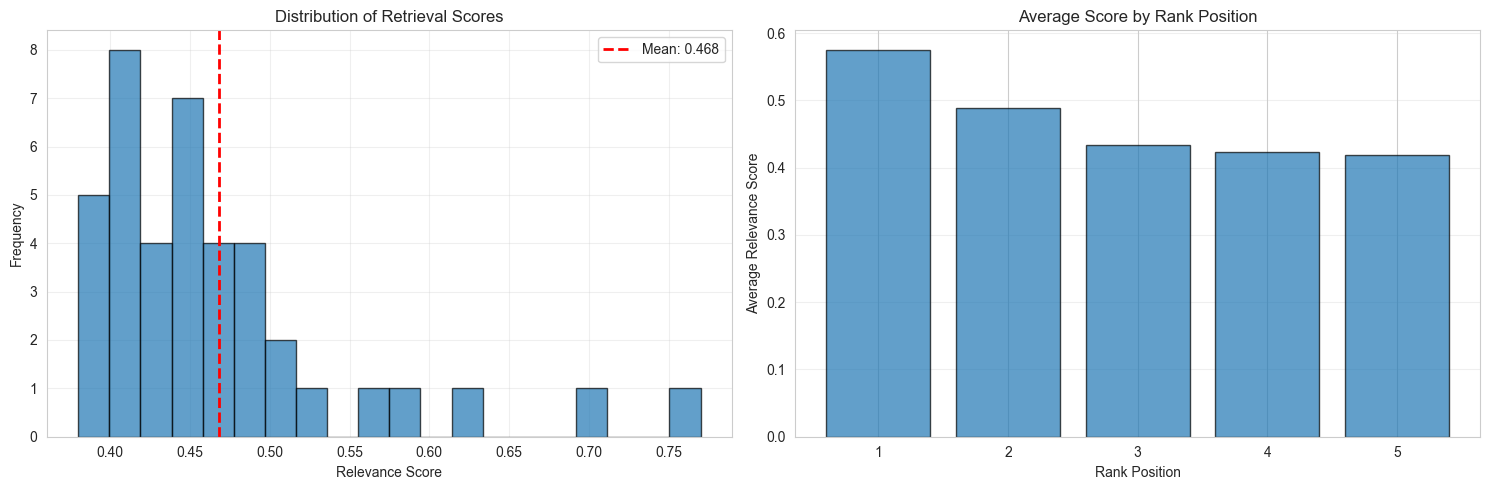


Key Observations:
--------------------------------------------------------------------------------
Average top result score: 0.5754
Score drop-off from rank 1 to 5: 0.1561
Overall average score: 0.4680


In [13]:
# Collect detailed scores for visualization
detailed_results = []

for query in test_queries:
    results = retrieve_documents(query, num_results=5)
    
    for idx, result in enumerate(results, 1):
        detailed_results.append({
            'Query': query[:30] + '...' if len(query) > 30 else query,
            'Rank': idx,
            'Score': result['score']
        })

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Score distribution
scores = [r['Score'] for r in detailed_results]
axes[0].hist(scores, bins=20, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Retrieval Scores')
axes[0].set_xlabel('Relevance Score')
axes[0].set_ylabel('Frequency')
axes[0].axvline(sum(scores)/len(scores), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {sum(scores)/len(scores):.3f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Score by rank position
rank_df = pd.DataFrame(detailed_results)
rank_avg = rank_df.groupby('Rank')['Score'].mean()
axes[1].bar(rank_avg.index, rank_avg.values, edgecolor='black', alpha=0.7)
axes[1].set_title('Average Score by Rank Position')
axes[1].set_xlabel('Rank Position')
axes[1].set_ylabel('Average Relevance Score')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("-"*80)
print(f"Average top result score: {rank_avg[1]:.4f}")
print(f"Score drop-off from rank 1 to 5: {(rank_avg[1] - rank_avg[5]):.4f}")
print(f"Overall average score: {sum(scores)/len(scores):.4f}")

---

## 10. Understanding Vector Search

Let's see how semantic similarity works by testing related queries.

In [14]:
# Test semantically similar queries
similar_queries = [
    "What is your return policy?",
    "Can I return items?",
    "How do I send something back?",
    "Return process"
]

print("Semantic Similarity Test:")
print("="*80)
print("Testing how different phrasings retrieve similar content\n")

for query in similar_queries:
    results = retrieve_documents(query, num_results=1)
    
    if results:
        top_result = results[0]
        score = top_result['score']
        source = top_result['location']['s3Location']['uri'].split('/')[-1]
        content = top_result['content']['text'][:100]
        
        print(f"Query: '{query}'")
        print(f"  Score: {score:.4f}")
        print(f"  Source: {source}")
        print(f"  Content: {content}...")
        print()

print("\nObservation:")
print("Despite different wording, semantically similar queries retrieve")
print("similar content, demonstrating the power of vector embeddings!")

Semantic Similarity Test:
Testing how different phrasings retrieve similar content

Query: 'What is your return policy?'
  Score: 0.5944
  Source: faq_3.txt
  Content: Q: What is your return policy?
A: Our return policy allows you to return products within 30 days of ...

Query: 'Can I return items?'
  Score: 0.4876
  Source: return_policy_3.txt
  Content: Non-returnable Items
Certain items cannot be returned for hygiene and safety reasons. These include ...

Query: 'How do I send something back?'
  Score: 0.4786
  Source: return_policy_1.txt
  Content: Return Process
To initiate a return, submit a return request through your account dashboard with you...

Query: 'Return process'
  Score: 0.4453
  Source: return_policy_1.txt
  Content: Return Process
To initiate a return, submit a return request through your account dashboard with you...


Observation:
Despite different wording, semantically similar queries retrieve
similar content, demonstrating the power of vector embeddings!


---

## Summary

In this notebook, we:

1. Connected to AWS Bedrock Knowledge Base
2. Explored Knowledge Base configuration and storage
3. Learned how to trigger and monitor ingestion jobs
4. Examined the structure of indexed documents
5. Tested retrieval with various queries
6. Visualized retrieval scores and patterns
7. Demonstrated semantic similarity in vector search

**Key Takeaways:**

- Knowledge Base stores documents as vector embeddings
- Retrieval scores indicate semantic similarity (0-1 range)
- Vector search understands meaning, not just keywords
- Top results typically have scores > 0.4 for relevant content
- Ingestion jobs sync S3 data to the vector store

**Next Steps:**

In Notebook 03, we'll build a complete RAG application that:
- Uses this Knowledge Base for retrieval
- Generates answers using the LLM
- Implements conversation memory
- Adds source attribution